# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

### 1. Exploratory Data Analysis (EDA):

In [2]:
data=pd.read_excel('glass.xlsx',sheet_name='glass')

In [3]:
data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
data.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [6]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


### 2: Data Visualization:

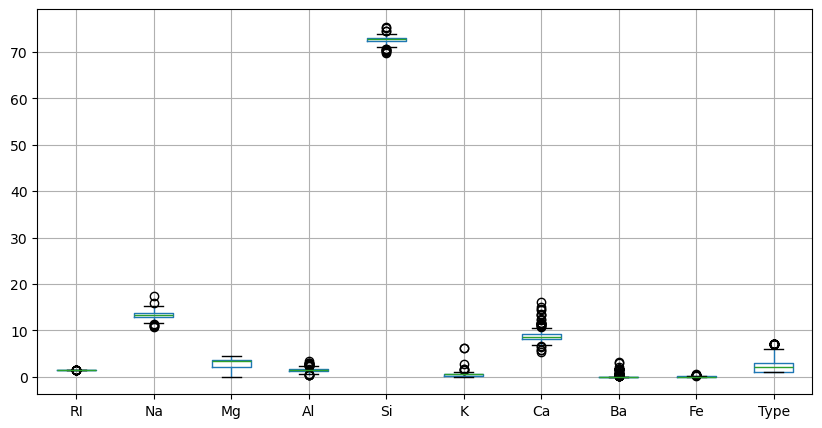

In [7]:
#boxplot
data.boxplot(figsize=(10,5))
plt.show()

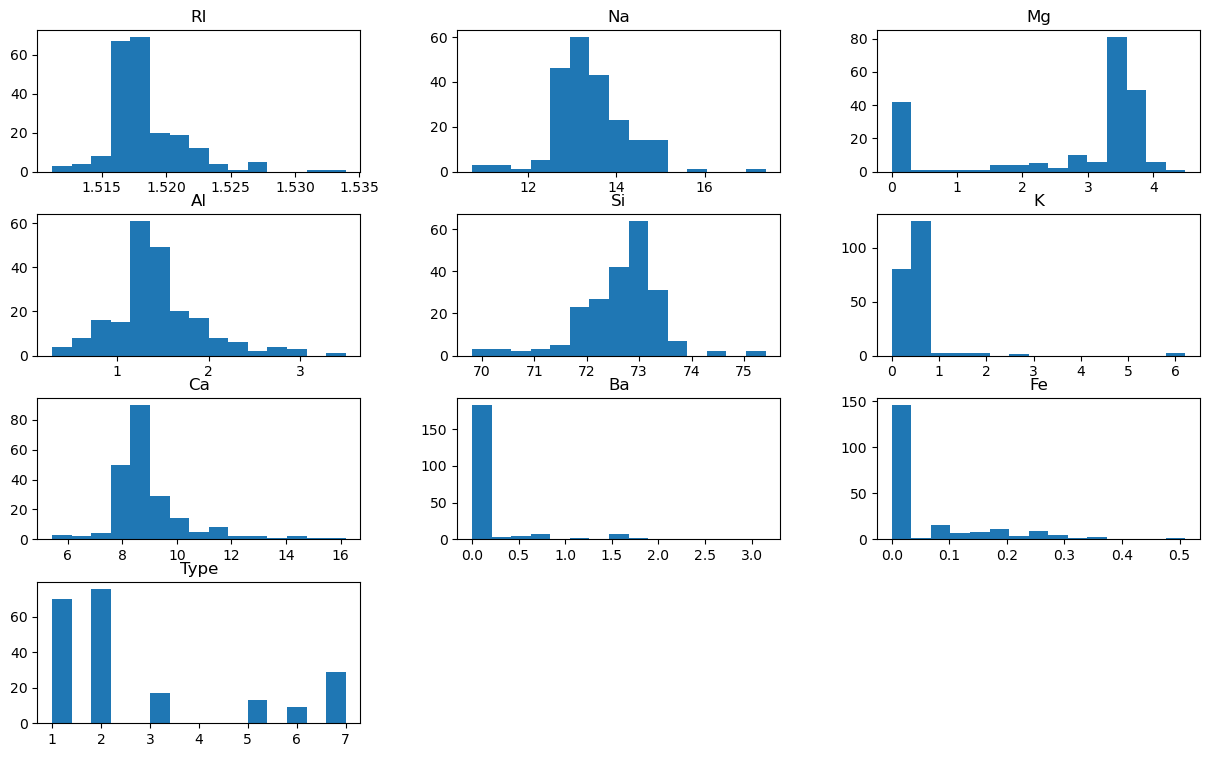

In [10]:
#histogram
data.hist(bins=15,figsize=(15,9),grid=False)
plt.show()

In [11]:
correaltion_matrix=data.corr()
correaltion_matrix

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278
Type,-0.164237,0.502898,-0.744993,0.598829,0.151565,-0.010054,0.000952,0.575161,-0.188278,1.000000


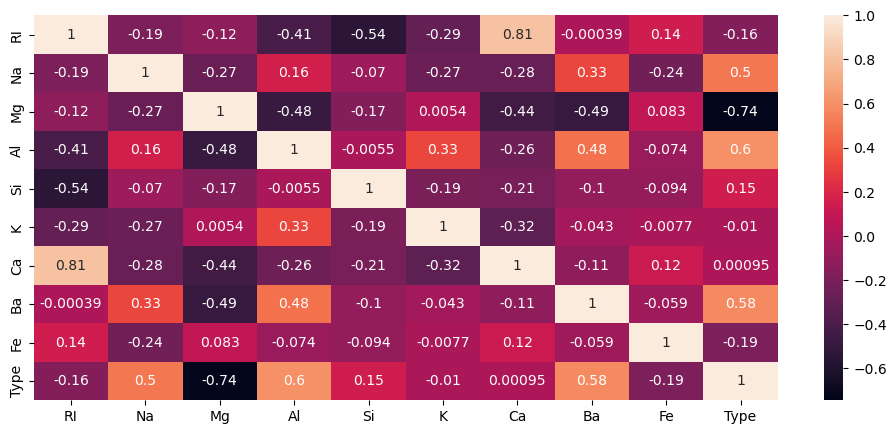

In [14]:
#correlation heatmap
plt.figure(figsize=(12,5))
sns.heatmap(correaltion_matrix,annot=True)
plt.show()

### 3: Data Preprocessing

In [15]:
data.isnull().sum() #there are no missing values so no imputation is required

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [16]:
#there are no categorical variables

### 4: Random Forest Model Implementation

In [17]:
features=data.drop('Type',axis=1)

In [18]:
features

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


In [19]:
target=data['Type']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [21]:
#spliting the data into train=70% and test=30%
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.3,random_state=42)

In [22]:
#Random Forest
model=RandomForestClassifier(n_estimators=50,max_features=3)
model.fit(x_train,y_train)

RandomForestClassifier(max_features=3, n_estimators=50)

In [23]:
ypred=model.predict(x_test)

In [24]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           1       0.77      0.89      0.83        19
           2       0.78      0.78      0.78        23
           3       0.67      0.50      0.57         4
           5       0.75      0.50      0.60         6
           6       0.75      1.00      0.86         3
           7       1.00      0.90      0.95        10

    accuracy                           0.80        65
   macro avg       0.79      0.76      0.76        65
weighted avg       0.80      0.80      0.80        65



### 5: Bagging and Boosting Methods

#### Bagging

In [25]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [26]:
dt=DecisionTreeClassifier()

In [27]:
#applying Bagging method using Decision Tree Classifier
model2=BaggingClassifier(dt,n_estimators=40)

In [28]:
model2.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=40)

In [29]:
y_preds=model2.predict(x_test)

In [30]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           1       0.65      0.89      0.76        19
           2       0.72      0.57      0.63        23
           3       0.67      0.50      0.57         4
           5       0.60      0.50      0.55         6
           6       0.75      1.00      0.86         3
           7       1.00      0.90      0.95        10

    accuracy                           0.72        65
   macro avg       0.73      0.73      0.72        65
weighted avg       0.73      0.72      0.72        65



#### Boosting

In [31]:
from sklearn.ensemble import AdaBoostClassifier

In [32]:
base_estimator=DecisionTreeClassifier()

In [33]:
#Applying Adaboost Classifier
model3=AdaBoostClassifier(base_estimator,n_estimators=40)

In [34]:
model3.fit(x_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=40)

In [35]:
y_pred=model3.predict(x_test)

In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.62      0.79      0.70        19
           2       0.71      0.52      0.60        23
           3       0.20      0.25      0.22         4
           5       0.75      0.50      0.60         6
           6       0.60      1.00      0.75         3
           7       0.90      0.90      0.90        10

    accuracy                           0.66        65
   macro avg       0.63      0.66      0.63        65
weighted avg       0.68      0.66      0.66        65



### Additional Notes:
#### 1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging trains models in parallel on bootstrapped subsets to reduce variance (e.g., Random Forest).
Boosting trains models sequentially, each correcting errors of the previous, reducing bias and variance (e.g., XGBoost).
Bagging uses majority vote/averaging, while Boosting uses weighted combinations.
Main difference → Bagging = independent learners, Boosting = dependent learners.

#### 2. Explain how to handle imbalance in the data.
Imbalance can be handled by resampling techniques like oversampling the minority class (e.g., SMOTE) or undersampling the majority class.
Another way is to use class weights or cost-sensitive learning so the model penalizes misclassification of minority class more.
Ensemble methods (e.g., Balanced Random Forest, XGBoost with scale_pos_weight) are also effective.
Additionally, use evaluation metrics like F1-score, Precision-Recall, or AUC instead of accuracy.